# For simulated data

We take badread and simulate reads. Record how the hazard ratio changes with respect to k, and its relationship with the k-mer hit rate.

In [3]:
kvmer_results = {
    "homogeneous_random": [0.957991340465147,
0.9580352830232076,
0.9586219314566953,
0.9585138621052368,
0.9580638839898099,
0.9582327674371037,
0.9571379781420765,
0.9583110318168302,
0.9538755119771627,
0.9608021729583788],
    "heterogeneous_random": [0.9682876086407031,
0.9688755020080321,
0.9687875647668394,
0.9693008728392949,
0.9708887858924276,
0.9708229142987043,
0.9713977965883414,
0.9715921417379776,
0.9685534591194969,
0.9743205512436282],
    "homogeneous_nanopore": [0.9643250427188153,
0.9643243881790081,
0.963994773270177,
0.9655303872668933,
0.9649249802579626,
0.965593671145059,
0.9661569610716766,
0.9657268872752084,
0.9627568979221074,
0.9665185884079621],
    "heterogeneous_nanopore": [0.9717054705093716,
0.9715218410705913,
0.9729054894462287,
0.9729046415112341,
0.9744937484677617,
0.9739670336305271,
0.9750069740770971,
0.9755001695489997,
0.9727883027722256,
0.9760918359370638]
}

k = 21

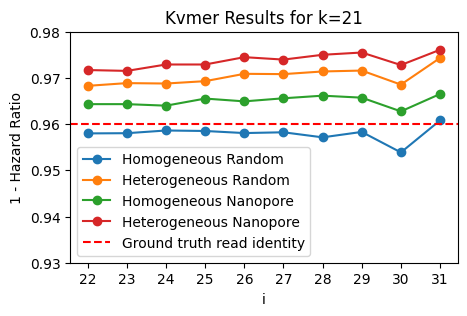

In [4]:
# Plot the change of hazard ratio with different k

import matplotlib.pyplot as plt
import numpy as np

x = k + np.arange(1, 11)
plt.figure(figsize=(5, 3))
plt.plot(x, kvmer_results["homogeneous_random"], marker='o', label='Homogeneous Random')
plt.plot(x, kvmer_results["heterogeneous_random"], marker='o', label='Heterogeneous Random')
plt.plot(x, kvmer_results["homogeneous_nanopore"], marker='o', label='Homogeneous Nanopore')
plt.plot(x, kvmer_results["heterogeneous_nanopore"], marker='o', label='Heterogeneous Nanopore')

# Also plot a horizontal line at y=0.95 for reference
plt.axhline(y=0.96, color='r', linestyle='--', label='Ground truth read identity')

plt.title(f'Kvmer Results for k={k}')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
plt.ylim(0.93, 0.98)
plt.xticks(x)
plt.legend()


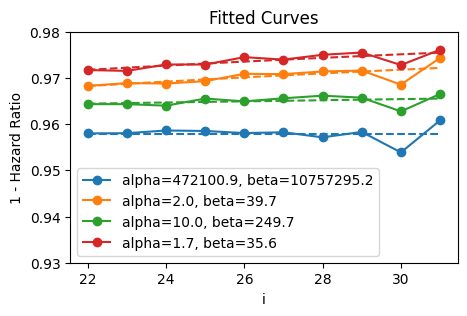

Fitted parameters for homogeneous_random: alpha = 472100.914790, beta = 10757295.235832
Fitted parameters for heterogeneous_random: alpha = 2.022498, beta = 39.656427
Fitted parameters for homogeneous_nanopore: alpha = 10.019626, beta = 249.663855
Fitted parameters for heterogeneous_nanopore: alpha = 1.673611, beta = 35.564815


In [35]:
from scipy.optimize import curve_fit

num_trim_values = 0
x = k + np.arange(1, 11)
# Define the function to fit
def fit_function(i, alpha, beta):
    return 1 - alpha / (alpha + beta + i)

# Fit the curves
fit_params = {}
for key, values in kvmer_results.items():
    i_values = x  # x is already defined as k + np.arange(1, 11)
    popt, _ = curve_fit(fit_function, i_values, values, p0=[1, 1])  # Initial guess for alpha and beta
    fit_params[key] = popt  # Store the fitted parameters

# Print the fitted parameters
# Plot the fitted curves
plt.figure(figsize=(5, 3))
i = 0
for key, values in kvmer_results.items():
    i_values = x
    fitted_curve = fit_function(i_values, *fit_params[key])
    plt.plot(i_values, fitted_curve, linestyle='--', color=f'C{i}')
    plt.plot(i_values, values, marker='o', label=f'alpha={fit_params[key][0]:.1f}, beta={fit_params[key][1]:.1f}', color=f'C{i}')
    i += 1

plt.title('Fitted Curves')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
plt.legend()
plt.ylim(0.93, 0.98)
plt.show()

for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: alpha = {alpha:.6f}, beta = {beta:.6f}")

In [36]:
for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: mean = {alpha / (alpha + beta)}, variance = {alpha * beta / ((alpha + beta)**2 * (alpha + beta + 1))}")

Fitted parameters for homogeneous_random: mean = 0.042041522843928876, variance = 3.5864822181183297e-09
Fitted parameters for heterogeneous_random: mean = 0.04852566583165765, variance = 0.001081820274220437
Fitted parameters for homogeneous_nanopore: mean = 0.03858399481637742, variance = 0.00014230004134412863
Fitted parameters for heterogeneous_nanopore: mean = 0.04494312546165571, variance = 0.0011225158941510884


In [38]:
# Calculate the mean for each case
means = {key: np.mean(values) for key, values in kvmer_results.items()}
for key, mean in means.items():
    print(f'Mean for {key}: {mean:.6f}')

Mean for homogeneous_random: 0.957959
Mean for heterogeneous_random: 0.970283
Mean for homogeneous_nanopore: 0.964985
Mean for heterogeneous_nanopore: 0.973689


[0.9579584808999518, 0.917684454714625, 0.8791036130553231, 0.84214477158991, 0.8067397387016595, 0.7728231896699442, 0.7403325461406111, 0.7092078606636564, 0.6793917060851606, 0.6508290695893999, 0.6234672511956303, 0.597255766522264, 0.5721462536390249, 0.548092383835219, 0.525049776139476, 0.5029759154332457, 0.48183007400695793, 0.4615732364141107, 0.44216802748463524, 0.4235786433647155, 0.40577078545582385, 0.3887115971310841, 0.37236960311219813, 0.3567146513950799, 0.3417178576170453, 0.32735155176290864, 0.31358922711165504, 0.30040549132948935, 0.2877760196190246, 0.27567750983816525, 0.26408763950587577, 0.2529850246155063, 0.242349180179682, 0.2321604824339577, 0.22240013262950076, 0.2130501223479954, 0.20409320027477232, 0.19551284036885652, 0.18729321137120417, 0.17941914759486877, 0.1718761209432017, 0.16465021410445832, 0.15772809487335118, 0.15109699155217154, 0.14474466938609198, 0.13865940798917112, 0.13282997971940977, 0.12724562896295813, 0.12189605228925209, 0.11

(0.0, 100.0)

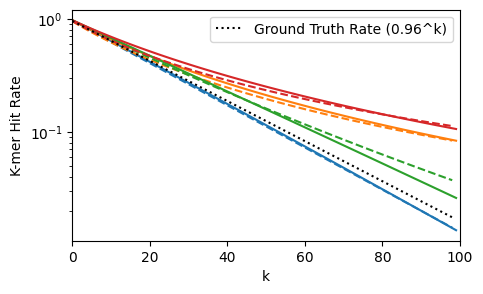

In [40]:
# Plot the k-mer hit rate and the predicted rates
import pandas as pd

kmer_hit_rate_csv = [
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_96_homogeneous.matched_kmers.csv",
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_96.matched_kmers.csv",
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_96_homogeneous_nanopore.matched_kmers.csv",
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_96_nanopore.matched_kmers.csv",
]
predicted_rates = [0.957959, 0.970283, 0.964985, 0.973689]
labels = [
    "Homogeneous Random",
    "Heterogeneous Random",
    "Homogeneous Nanopore",
    "Heterogeneous Nanopore",
]

plt.figure(figsize=(5, 3))


for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    kmer_hit_rates = kmer_hit_rate_df['num_kmer_hit'].values
    plt.plot(kmer_hit_rates, color=f'C{i}')

    # predicted rate line
    #predicted_hit_rates = predicted_rates[i] ** np.arange(1, len(kmer_hit_rates) + 1)
    #plt.plot(predicted_hit_rates, linestyle='--', label=f'{labels[i]} Predicted Rate', color=f'C{i}')

    params = fit_params[list(kvmer_results.keys())[i]]
    alpha, beta = params
    predicted_rates = []
    for j in range(1, len(kmer_hit_rates)):
        rate = 1 - alpha / (alpha + beta + j)
        if len(predicted_rates) == 0:
            predicted_rates.append(rate)
        else:
            predicted_rates.append(predicted_rates[-1] * rate)
    print(predicted_rates)
    plt.plot(predicted_rates, linestyle='--', color=f'C{i}')


# also plot a line 0.96 ** k for reference
plt.plot(0.96 ** np.arange(1, len(predicted_rates) + 1), color='k', linestyle=':', label='Ground Truth Rate (0.96^k)')

plt.ylabel('K-mer Hit Rate')
plt.xlabel('k')
plt.yscale('log')
plt.legend()
plt.xlim(0, 100)


(0.0, 100.0)

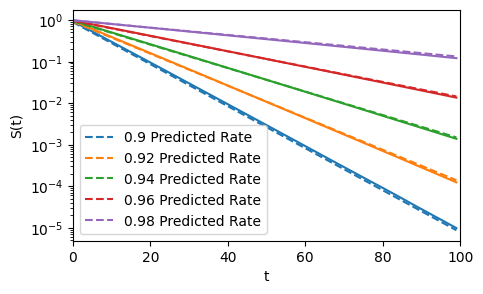

In [41]:
# Plot the k-mer hit rate and the predicted rates
import pandas as pd

kmer_hit_rate_csv = [
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_90_homogeneous.matched_kmers.csv",
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_92_homogeneous.matched_kmers.csv",
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_94_homogeneous.matched_kmers.csv",
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_96_homogeneous.matched_kmers.csv",
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_98_homogeneous.matched_kmers.csv"
]
predicted_rates = [0.89, 0.915, 0.937, 0.9585, 0.98]
labels = [
    "0.9",
    "0.92",
    "0.94",
    "0.96",
    "0.98"
]

plt.figure(figsize=(5, 3))


for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    kmer_hit_rates = kmer_hit_rate_df['num_kmer_hit'].values
    plt.plot(kmer_hit_rates, color=f'C{i}')
    

    # predicted rate line
    predicted_hit_rates = predicted_rates[i] ** np.arange(1, len(kmer_hit_rates) + 1)
    plt.plot(predicted_hit_rates, linestyle='--', label=f'{labels[i]} Predicted Rate', color=f'C{i}')

    """

    params = fit_params[list(kvmer_results.keys())[i]]
    alpha, beta = params
    predicted_rates = []
    for j in range(1, len(kmer_hit_rates)):
        rate = 1 - alpha / (alpha + beta + j)
        if len(predicted_rates) == 0:
            predicted_rates.append(rate)
        else:
            predicted_rates.append(predicted_rates[-1] * rate)
    print(predicted_rates)
    plt.plot(predicted_rates, linestyle='--', color=f'C{i}')
    """


# also plot a line 0.96 ** k for reference
#plt.plot(0.96 ** np.arange(1, len(predicted_rates) + 1), color='k', linestyle=':', label='Ground Truth Rate (0.96^k)')

plt.ylabel('S(t)')
plt.xlabel('t')
plt.yscale('log')
plt.legend()
plt.xlim(0, 100)


In [9]:
len(predicted_rates)

99

# For real data

In [17]:
kvmer_results_with_reference = {
    "ERR3152366": [
        0.9488160285031892,
0.9513522166782097,
0.9506263065396683,
0.9507804517027733,
0.95071898683373,
0.952689482419854,
0.9506252174500059,
0.9499507687853614
    ],
    "ERR2935851": [
        0.9968654662741705,
0.9969280364832004,
0.9969245010221599,
0.9969100557533418,
0.9970402129733851,
0.9969827982843921,
0.9969699152656839,
0.9969652219858829
    ],
    "SRR7415629": [
        0.8709636705103092,
0.8719430548873445,
0.8724347681568888,
0.8736169953366454,
0.8757784561709551,
0.8732869890845351,
0.8723498888065233,
0.8717120744653035
    ]
}

In [46]:
kvmer_results_without_reference = {
    "ERR3152366": [
        0.9400003255935495,
0.9468985957488596,
0.9483031475626089,
0.9504484352189763,
0.9511072878195201,
0.9526514468316107,
0.9522470697296405,
0.9524957549991356
    ],
    "ERR2935851": [
        0.9962360386810292,
0.9968025414638172,
0.9968153862517284,
0.9968324911427558,
0.9969563487421811,
0.9969186357074373,
0.996896197317835,
0.996920019749417
    ],
    "SRR7415629": [
        0.8742048065029157,
0.8760643808272481,
0.8770405514536225,
0.8784560365026514,
0.8818635295879309,
0.8812879398904784,
0.8813612388911635,
0.8807350730974177
    ]
}

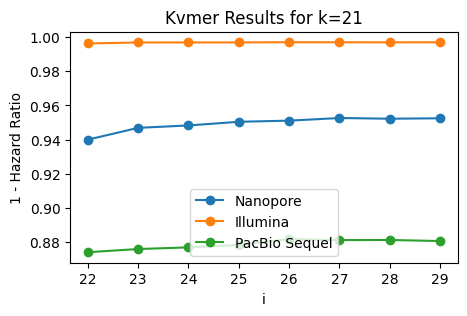

In [47]:
# Plot the change of hazard ratio with different k

import matplotlib.pyplot as plt
import numpy as np
data = kvmer_results_without_reference
x = k + np.arange(1, len(data["ERR3152366"]) + 1)

plt.figure(figsize=(5, 3))
plt.plot(x, data["ERR3152366"], marker='o', label='Nanopore')
plt.plot(x, data["ERR2935851"], marker='o', label='Illumina')
plt.plot(x, data["SRR7415629"], marker='o', label='PacBio Sequel')


plt.title(f'Kvmer Results for k={k}')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
#plt.ylim(0.93, 0.)
plt.xticks(x)
plt.legend()


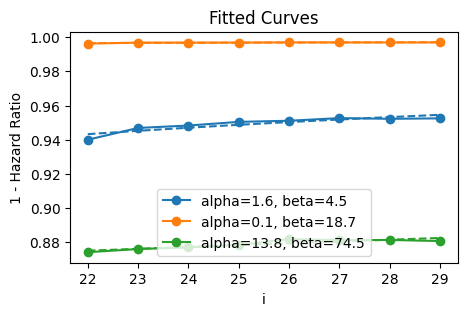

Fitted parameters for ERR3152366: alpha = 1.596410, beta = 4.542880
Fitted parameters for ERR2935851: alpha = 0.141760, beta = 18.742077
Fitted parameters for SRR7415629: alpha = 13.769049, beta = 74.455373


In [48]:
from scipy.optimize import curve_fit

# Define the function to fit
def fit_function(i, alpha, beta):
    return 1 - alpha / (alpha + beta + i)

# Fit the curves
fit_params = {}
for key, values in data.items():
    i_values = x  # x is already defined as k + np.arange(1, 11)
    popt, _ = curve_fit(fit_function, i_values, values, p0=[1, 1])  # Initial guess for alpha and beta
    fit_params[key] = popt  # Store the fitted parameters

# Print the fitted parameters
# Plot the fitted curves
plt.figure(figsize=(5, 3))
i = 0
for key, values in data.items():
    i_values = x
    fitted_curve = fit_function(i_values, *fit_params[key])
    plt.plot(i_values, fitted_curve, linestyle='--', color=f'C{i}')
    plt.plot(i_values, values, marker='o', label=f'alpha={fit_params[key][0]:.1f}, beta={fit_params[key][1]:.1f}', color=f'C{i}')
    i += 1

plt.title('Fitted Curves')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
plt.legend()
#plt.ylim(0.93, 0.98)
plt.show()

for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: alpha = {alpha:.6f}, beta = {beta:.6f}")

In [49]:
for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: mean = {alpha / (alpha + beta)}, variance = {alpha * beta / ((alpha + beta)**2 * (alpha + beta + 1))}")

Fitted parameters for ERR3152366: mean = 0.2600317285240762, variance = 0.02695158941140845
Fitted parameters for ERR2935851: mean = 0.007506973435254094, variance = 0.00037470728142258505
Fitted parameters for SRR7415629: mean = 0.1560684513436434, variance = 0.0014761775563374927


[0.8456807160606179, 0.7166223204882276, 0.6084582174160829, 0.5176157835286916, 0.4411650328560374, 0.37669742680845536, 0.3222285711549336, 0.27611989243651086, 0.2370154346467481, 0.20379073301248288, 0.17551135868512857, 0.15139922677648213, 0.13080515156404862, 0.11318644073384083, 0.09808856360823438, 0.08513012061475303, 0.07399049377481177, 0.06439967925734051, 0.05612989968831333, 0.04898867111320849, 0.04281306132782978, 0.037464925902343786, 0.0328269481231639, 0.02879934123741627, 0.02529709736157789, 0.022247688442026257, 0.019589141708974606, 0.017268425924804674, 0.015240096013575163, 0.013465152866164936, 0.011910082641971345, 0.010546046051728163, 0.009348193162806467, 0.008295083424508486, 0.007368194032778681, 0.006551502576015416, 0.005831132235303322, 0.00519504974190205, 0.004632807894188151, 0.004135325764079481, 0.0036947008271185273, 0.0033040481699625874, 0.0029573626960509277, 0.002649400890960959, 0.0023755792450092334, 0.0021318868797591695, 0.0019148103019

/tmp/ipykernel_3750/881900453.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


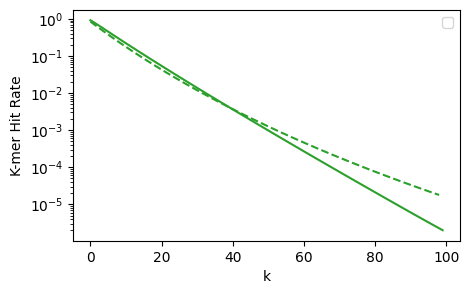

In [52]:
# Plot the k-mer hit rate and the predicted rates
import pandas as pd

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7415629_ref.matched_kmers.csv",
]
predicted_rates = [0.957959, 0.970283, 0.964985, 0.973689]
labels = [
    "Nanopore",
    "Illumina",
    "PacBio Sequel",
]

plt.figure(figsize=(5, 3))


for i in range(len(kmer_hit_rate_csv)):
    if i != 2:
        continue
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    kmer_hit_rates = kmer_hit_rate_df['num_kmer_hit'].values
    plt.plot(kmer_hit_rates, color=f'C{i}')

    # predicted rate line
    #predicted_hit_rates = predicted_rates[i] ** np.arange(1, len(kmer_hit_rates) + 1)
    #plt.plot(predicted_hit_rates, linestyle='--', label=f'{labels[i]} Predicted Rate', color=f'C{i}')

    params = fit_params[list(data.keys())[i]]
    alpha, beta = params
    predicted_rates = []
    for j in range(1, len(kmer_hit_rates)):
        rate = 1 - alpha / (alpha + beta + j)
        if len(predicted_rates) == 0:
            predicted_rates.append(rate)
        else:
            predicted_rates.append(predicted_rates[-1] * rate)
    print(predicted_rates)
    plt.plot(predicted_rates, linestyle='--', color=f'C{i}')


# also plot a line 0.96 ** k for reference
#plt.plot(0.96 ** np.arange(1, len(predicted_rates) + 1), color='k', linestyle=':', label='Ground Truth Rate (0.96^k)')

plt.ylabel('K-mer Hit Rate')
plt.xlabel('k')
plt.yscale('log')
plt.legend()
#plt.xlim(0, 50)


# Plotting survival rate

/tmp/ipykernel_7065/60360524.py:10: RuntimeWarning: overflow encountered in exp
  return np.exp(- alpha - beta * i)
/tmp/ipykernel_7065/60360524.py:10: RuntimeWarning: overflow encountered in exp
  return np.exp(- alpha - beta * i)
/tmp/ipykernel_7065/60360524.py:10: RuntimeWarning: overflow encountered in exp
  return np.exp(- alpha - beta * i)
/tmp/ipykernel_7065/60360524.py:10: RuntimeWarning: overflow encountered in exp
  return np.exp(- alpha - beta * i)


Fitted parameters: alpha = 0.183874, beta = 0.050969
Fitted parameters for mean = 0.7829664065567239, variance = 0.1376126822948648
Fitted parameters: alpha = 0.015917, beta = 0.001897
Fitted parameters for mean = 0.8934943973927851, variance = 0.09349654962261579
Fitted parameters: alpha = 0.116674, beta = 0.103009
Fitted parameters for mean = 0.5311028711306275, variance = 0.20417821482377993
Fitted parameters: alpha = 0.104425, beta = 0.005414
Fitted parameters for mean = 0.9507106839406181, variance = 0.04222221935087943


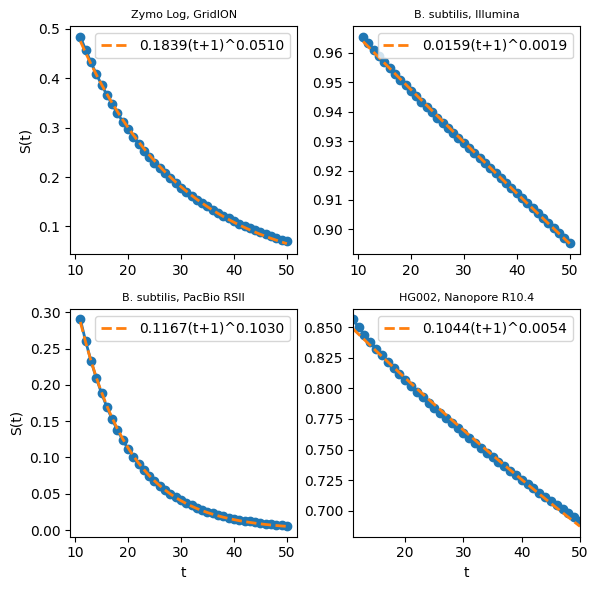

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns


# Define the function to fit
def fit_function_constant(i, alpha, beta):
    return np.exp(- alpha - beta * i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean * i + (std ** 2) * (i ** 2) / 2)

def fit_function_discrete_weibull(i, l, k):
    return l ** ((i + 1) ** k)


kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/ERR2935851_trim_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv",
    "../../output/human/HG002.bam.tmp.0000.matched_kmers.csv"
]

labels = [
    "Zymo Log, GridION",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    "HG002, Nanopore R10.4",
]

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
hazard_ratio_plot_range = range(11, 51)
hazard_ratio_estimate_range = range(11, 51)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

func = fit_function_discrete_weibull
func = fit_function_constant

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values

    
    survival_rates_esimates = survival_rates[hazard_ratio_estimate_range.start - 1:hazard_ratio_estimate_range.stop - 1]
    survival_rates_plot = survival_rates[hazard_ratio_plot_range.start - 1:hazard_ratio_plot_range.stop - 1]
    
    # Fit the curve alpha/(alpha + beta + t) to the hazard ratios
    params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
    alpha, bet = params
    print(f"Fitted parameters: alpha = {alpha:.6f}, beta = {bet:.6f}")

    mean = alpha / (alpha + bet)
    variance = alpha * bet / ((alpha + bet)**2 * (alpha + bet + 1))
    print(f"Fitted parameters for mean = {mean}, variance = {variance}")
    #axes[i].set_yscale('log')
    #axes[i].set_xscale('log')

    axes[i].plot(hazard_ratio_plot_range, survival_rates_plot, linewidth=2, marker='o', color='C0')
    fitted_hazard_ratios = [func(t, alpha, bet) for t in hazard_ratio_plot_range]
    axes[i].plot(hazard_ratio_plot_range, fitted_hazard_ratios, linewidth=2, linestyle='--', label=f'{alpha:.4f}(t+1)^{bet:.4f}', color='C1')
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i], fontsize=font_size)
    if i >= 2:
        axes[i].set_xlabel('t')
    if i % 2 == 0:
        axes[i].set_ylabel('S(t)')
    axes[i].legend()
    

plt.tight_layout()

plt.xlim(hazard_ratio_plot_range.start, hazard_ratio_plot_range.stop - 1)
plt.show()
#plt.ylim(0, 0.05)

# Plotting hazard ratio

Fitted parameters: alpha = 0.079463, beta = -0.149825
Fitted parameters for mean = -1.1293498832148927, variance = -2.5867929397935994
Fitted parameters: alpha = 0.003008, beta = -0.147684
Fitted parameters for mean = -0.020789663323105813, variance = -0.02481150559848121
Fitted parameters: alpha = 0.133534, beta = -0.106901
Fitted parameters for mean = 5.013750892351344, variance = -19.601878076261833
Fitted parameters: alpha = 0.001395, beta = -0.061212
Fitted parameters for mean = -0.023324938622617062, variance = -0.02538759947175672


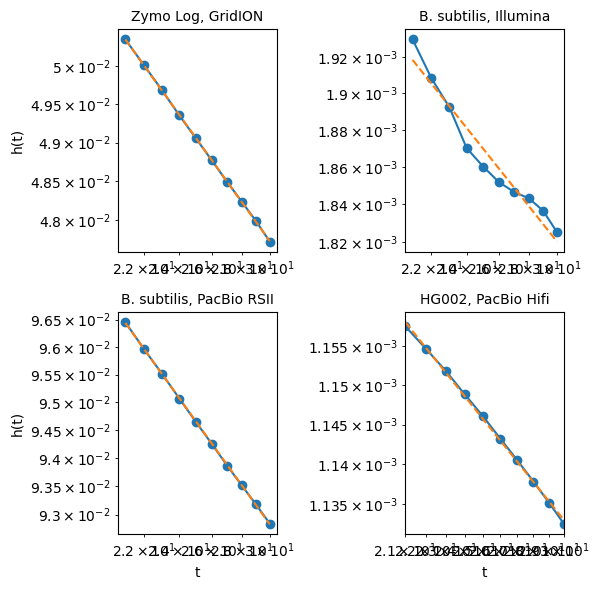

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style
#sns.set(style="whitegrid")

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_exp(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return 1 - ((beta + i) / (beta + i + 1)) ** alpha

def fit_function_discrete_weibull(i, l, k):
    return 1 - np.exp(-l * ((i+1) ** k - i ** k))


kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/ERR2935851_trim_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv",
    "../../output/human/HG002_hifi.bam.tmp.0000.matched_kmers.csv"
]

labels = [
    "Zymo Log, GridION",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    "HG002, PacBio Hifi",
]

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
hazard_ratio_plot_range = range(21, 31)
hazard_ratio_estimate_range = range(21, 31)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values

    hazard_ratios = []
    for j in range(1, len(survival_rates)):
        hazard_ratio = 1 - (survival_rates[j] / survival_rates[j - 1])
        hazard_ratios.append(hazard_ratio)
    
    hazard_ratio_esimates = hazard_ratios[hazard_ratio_estimate_range.start - 1:hazard_ratio_estimate_range.stop - 1]
    hazard_ratio_plot = hazard_ratios[hazard_ratio_plot_range.start - 1:hazard_ratio_plot_range.stop - 1]
    
    # Fit the curve alpha/(alpha + beta + t) to the hazard ratios
    params, _ = curve_fit(fit_function_exp, list(hazard_ratio_estimate_range), hazard_ratio_esimates)
    alpha, bet = params
    print(f"Fitted parameters: alpha = {alpha:.6f}, beta = {bet:.6f}")

    mean = alpha / (alpha + bet)
    variance = alpha * bet / ((alpha + bet)**2 * (alpha + bet + 1))
    print(f"Fitted parameters for mean = {mean}, variance = {variance}")
    axes[i].set_yscale('log')
    axes[i].set_xscale('log')

    axes[i].plot(hazard_ratio_plot_range, hazard_ratio_plot, marker='o', label='Observed Hazard Ratio', color='C0')
    fitted_hazard_ratios = [fit_function_exp(t, alpha, bet) for t in hazard_ratio_plot_range]
    axes[i].plot(hazard_ratio_plot_range, fitted_hazard_ratios, linestyle='--', label=f'Fitted Curve', color='C1')
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i], fontsize=10)
    if i >= 2:
        axes[i].set_xlabel('t')
    if i % 2 == 0:
        axes[i].set_ylabel('h(t)')
    #axes[i].legend()
    

plt.tight_layout()

plt.xlim(hazard_ratio_plot_range.start, hazard_ratio_plot_range.stop - 1)
plt.show()
#plt.ylim(0, 0.05)

# Plot hazard rate predictions

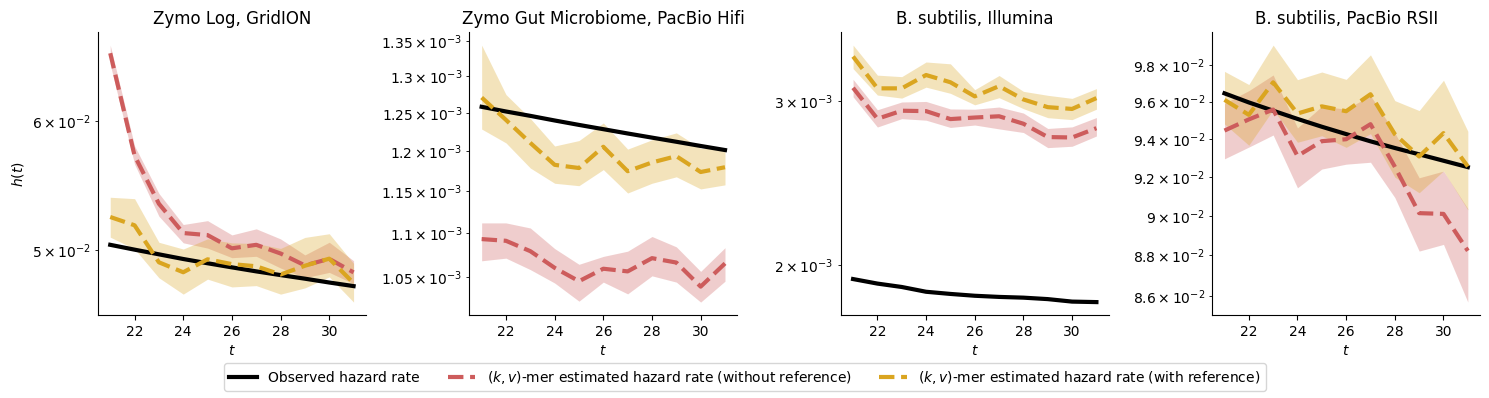

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/SRR13128014.matched_kmers.csv",
    "../../output/zymo/ERR2935851_trim_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv"
]


t_range = [
    range(21, 32),
    range(21, 32),
    range(21, 32),
    range(21, 32)
]

labels = [
    "Zymo Log, GridION",
    "Zymo Gut Microbiome, PacBio Hifi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII"
]

kvmer_hazard_rate_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_hazard_ratio.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_hazard_ratio.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_hazard_ratio.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_hazard_ratio.csv"
]

kvmer_ref_hazard_rate_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_ref_hazard_ratio.csv"
]



mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.992763,
    0.868784,
    0.963613
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    27.7,
    9.0,
    30.1
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.613276,
    11.7262,
    1.076,
]



hazard_rate_estimates = []

for i in range(len(kvmer_hazard_rate_csv)):
    kvmer_report_df = pd.read_csv(kvmer_hazard_rate_csv[i])
    hazard_rate = kvmer_report_df['hazard_ratio'].values
    percentile_5th = kvmer_report_df['5th_percentile'].values
    percentile_95th = kvmer_report_df['95th_percentile'].values
    hazard_rate_res = {"hazard_rate": hazard_rate,
                             "percentile_5th": percentile_5th,
                             "percentile_95th": percentile_95th}
    hazard_rate_estimates.append(hazard_rate_res)

hazard_rate_estimates_ref = []
for i in range(len(kvmer_ref_hazard_rate_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_hazard_rate_csv[i])
    hazard_rate = kvmer_report_df['hazard_ratio'].values
    percentile_5th = kvmer_report_df['5th_percentile'].values
    percentile_95th = kvmer_report_df['95th_percentile'].values
    hazard_rate_res = {"hazard_rate": hazard_rate,
                             "percentile_5th": percentile_5th,
                             "percentile_95th": percentile_95th}
    hazard_rate_estimates_ref.append(hazard_rate_res)
    

def q_score_to_error_rate(q):
    return 10 ** (-q / 10)

def kmer_error_to_error_rate(e):
    return (e / 100)


# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    plot_range = t_range[i]
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]
    hazard_ratios = []
    for j in range(1, len(survival_rates)):
        hazard_ratio = 1 - (survival_rates[j] / survival_rates[j - 1])
        hazard_ratios.append(hazard_ratio)
    
    hazard_ratio_plot = hazard_ratios[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    estimated_hr = hazard_rate_estimates[i]['hazard_rate']
    estimated_hr_upper = hazard_rate_estimates[i]['percentile_95th']
    estimated_hr_lower = hazard_rate_estimates[i]['percentile_5th']
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)


    axes[i].plot(plot_range, hazard_ratio_plot, linewidth=3,  label='Observed hazard rate', color='black')
    axes[i].plot(plot_range, estimated_hr, linewidth=3,  linestyle='--', label='$(k,v)$-mer estimated hazard rate (without reference)', color='indianred')
    axes[i].fill_between(plot_range, estimated_hr_lower, estimated_hr_upper,  linewidth=0, color='indianred', alpha=0.3)

    axes[i].plot(plot_range, hazard_rate_estimates_ref[i]['hazard_rate'], linewidth=3,   linestyle='--', label='$(k,v)$-mer estimated hazard rate (with reference)', color='goldenrod')
    axes[i].fill_between(plot_range, hazard_rate_estimates_ref[i]['percentile_5th'],  hazard_rate_estimates_ref[i]['percentile_95th'], linewidth=0, color='goldenrod', alpha=0.3)
    #axes[i].plot(plot_range, [1 - mapping_results[i]] * len(plot_range), linewidth=2, linestyle='--', color='C4', label='Reported Mapping Identity')

    #axes[i].plot(plot_range, [q_score_to_error_rate(q_score_results[i])] * len(plot_range), linewidth=2, linestyle='--', color='C2', label='Predicted from Q Score')
    #axes[i].plot(plot_range, [kmer_error_to_error_rate(kmer_results[i])] * len(plot_range), linewidth=2, linestyle='--', color='C3', label='Predicted from K-mer Error Rate')


    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    #axes[i].set_ylim(bottom=0)
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$h(t)$')
    #axes[i].legend()
    #axes[i].legend()

plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=5)
fig.subplots_adjust(bottom=0.2)


plt.show()
#plt.ylim(0, 0.05)

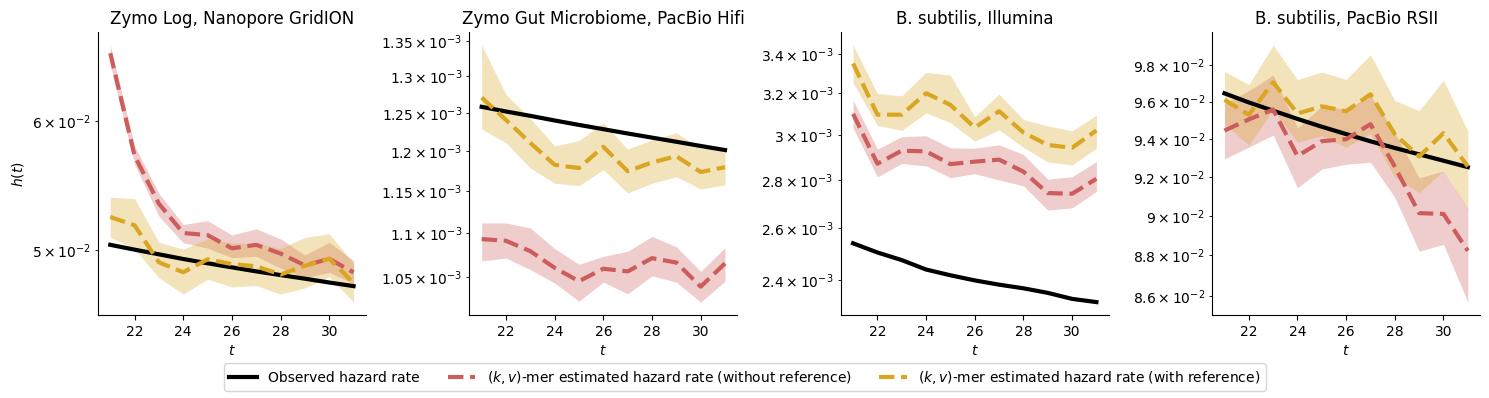

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/SRR13128014.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv"
]


t_range = [
    range(21, 32),
    range(21, 32),
    range(21, 32),
    range(21, 32)
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio Hifi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII"
]

kvmer_hazard_rate_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_hazard_ratio.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_hazard_ratio.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_hazard_ratio.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_hazard_ratio.csv"
]

kvmer_ref_hazard_rate_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_ref_hazard_ratio.csv"
]



mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.992763,
    0.868784,
    0.963613
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    27.7,
    9.0,
    30.1
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.613276,
    11.7262,
    1.076,
]



hazard_rate_estimates = []

for i in range(len(kvmer_hazard_rate_csv)):
    kvmer_report_df = pd.read_csv(kvmer_hazard_rate_csv[i])
    hazard_rate = kvmer_report_df['hazard_ratio'].values
    percentile_5th = kvmer_report_df['5th_percentile'].values
    percentile_95th = kvmer_report_df['95th_percentile'].values
    hazard_rate_res = {"hazard_rate": hazard_rate,
                             "percentile_5th": percentile_5th,
                             "percentile_95th": percentile_95th}
    hazard_rate_estimates.append(hazard_rate_res)

hazard_rate_estimates_ref = []
for i in range(len(kvmer_ref_hazard_rate_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_hazard_rate_csv[i])
    hazard_rate = kvmer_report_df['hazard_ratio'].values
    percentile_5th = kvmer_report_df['5th_percentile'].values
    percentile_95th = kvmer_report_df['95th_percentile'].values
    hazard_rate_res = {"hazard_rate": hazard_rate,
                             "percentile_5th": percentile_5th,
                             "percentile_95th": percentile_95th}
    hazard_rate_estimates_ref.append(hazard_rate_res)
    

def q_score_to_error_rate(q):
    return 10 ** (-q / 10)

def kmer_error_to_error_rate(e):
    return (e / 100)


# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    plot_range = t_range[i]
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]
    hazard_ratios = []
    for j in range(1, len(survival_rates)):
        hazard_ratio = 1 - (survival_rates[j] / survival_rates[j - 1])
        hazard_ratios.append(hazard_ratio)
    
    hazard_ratio_plot = hazard_ratios[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    estimated_hr = hazard_rate_estimates[i]['hazard_rate']
    estimated_hr_upper = hazard_rate_estimates[i]['percentile_95th']
    estimated_hr_lower = hazard_rate_estimates[i]['percentile_5th']
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)


    axes[i].plot(plot_range, hazard_ratio_plot, linewidth=3,  label='Observed hazard rate', color='black')
    axes[i].plot(plot_range, estimated_hr, linewidth=3,  linestyle='--', label='$(k,v)$-mer estimated hazard rate (without reference)', color='indianred')
    axes[i].fill_between(plot_range, estimated_hr_lower, estimated_hr_upper,  linewidth=0, color='indianred', alpha=0.3)

    axes[i].plot(plot_range, hazard_rate_estimates_ref[i]['hazard_rate'], linewidth=3,   linestyle='--', label='$(k,v)$-mer estimated hazard rate (with reference)', color='goldenrod')
    axes[i].fill_between(plot_range, hazard_rate_estimates_ref[i]['percentile_5th'],  hazard_rate_estimates_ref[i]['percentile_95th'], linewidth=0, color='goldenrod', alpha=0.3)
    #axes[i].plot(plot_range, [1 - mapping_results[i]] * len(plot_range), linewidth=2, linestyle='--', color='C4', label='Reported Mapping Identity')

    #axes[i].plot(plot_range, [q_score_to_error_rate(q_score_results[i])] * len(plot_range), linewidth=2, linestyle='--', color='C2', label='Predicted from Q Score')
    #axes[i].plot(plot_range, [kmer_error_to_error_rate(kmer_results[i])] * len(plot_range), linewidth=2, linestyle='--', color='C3', label='Predicted from K-mer Error Rate')


    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    #axes[i].set_ylim(bottom=0)
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$h(t)$')
    #axes[i].legend()
    #axes[i].legend()

plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=5)
fig.subplots_adjust(bottom=0.2)


plt.savefig("../../figures/figure3_A.pdf")
#plt.ylim(0, 0.05)

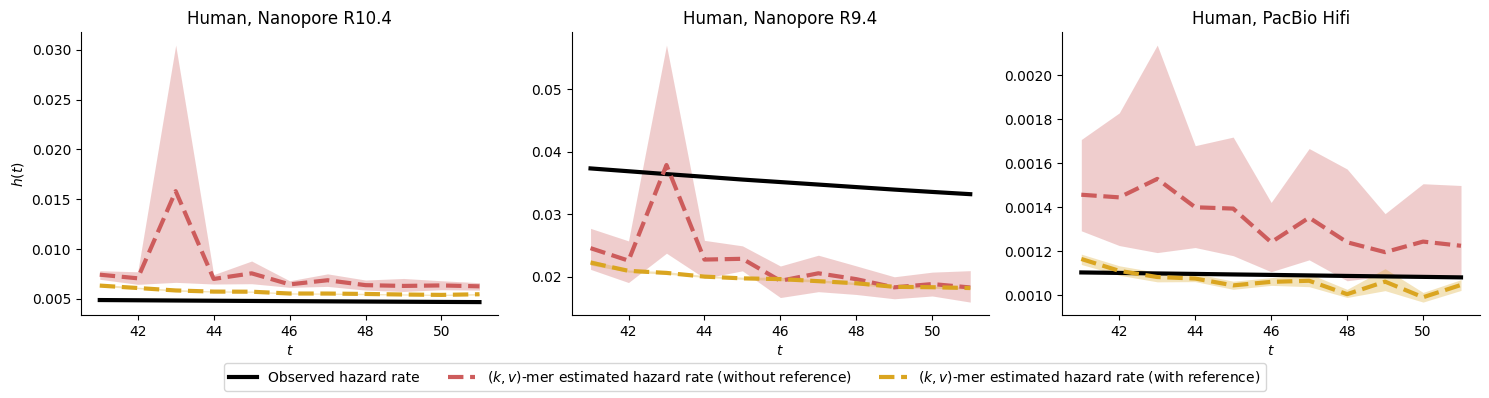

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit

kmer_hit_rate_csv = [
    "../../output/human/HG002.bam.tmp.0000.matched_kmers.csv",
    "../../output/human/HG002_R941.bam.tmp.0000.matched_kmers.csv",
    "../../output/human/HG002_hifi.bam.tmp.0000.matched_kmers.csv",
]


t_range = [
    range(41, 52),
    range(41, 52),
    range(41, 52),
]

labels = [
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio Hifi",
]

kvmer_hazard_rate_csv = [
    "../../output/human/HG002_bi_kvmer_hazard_ratio.csv",
    "../../output/human/HG002_R941_bi_kvmer_hazard_ratio.csv",
    "../../output/human/HG002_hifi_bi_kvmer_hazard_ratio.csv",
]

kvmer_ref_hazard_rate_csv = [
    "../../output/human/HG002_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/human/HG002_R941_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/human/HG002_hifi_bi_kvmer_ref_hazard_ratio.csv",
]



mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.992763,
    0.868784,
    0.963613
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    27.7,
    9.0,
    30.1
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.613276,
    11.7262,
    1.076,
]



hazard_rate_estimates = []

for i in range(len(kvmer_hazard_rate_csv)):
    kvmer_report_df = pd.read_csv(kvmer_hazard_rate_csv[i])
    hazard_rate = kvmer_report_df['hazard_ratio'].values
    percentile_5th = kvmer_report_df['5th_percentile'].values
    percentile_95th = kvmer_report_df['95th_percentile'].values
    hazard_rate_res = {"hazard_rate": hazard_rate,
                             "percentile_5th": percentile_5th,
                             "percentile_95th": percentile_95th}
    hazard_rate_estimates.append(hazard_rate_res)

hazard_rate_estimates_ref = []
for i in range(len(kvmer_ref_hazard_rate_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_hazard_rate_csv[i])
    hazard_rate = kvmer_report_df['hazard_ratio'].values
    percentile_5th = kvmer_report_df['5th_percentile'].values
    percentile_95th = kvmer_report_df['95th_percentile'].values
    hazard_rate_res = {"hazard_rate": hazard_rate,
                             "percentile_5th": percentile_5th,
                             "percentile_95th": percentile_95th}
    hazard_rate_estimates_ref.append(hazard_rate_res)
    

def q_score_to_error_rate(q):
    return 10 ** (-q / 10)

def kmer_error_to_error_rate(e):
    return (e / 100)


# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    plot_range = t_range[i]
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]
    hazard_ratios = []
    for j in range(1, len(survival_rates)):
        hazard_ratio = 1 - (survival_rates[j] / survival_rates[j - 1])
        hazard_ratios.append(hazard_ratio)
    
    hazard_ratio_plot = hazard_ratios[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    estimated_hr = hazard_rate_estimates[i]['hazard_rate']
    estimated_hr_upper = hazard_rate_estimates[i]['percentile_95th']
    estimated_hr_lower = hazard_rate_estimates[i]['percentile_5th']
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)


    axes[i].plot(plot_range, hazard_ratio_plot, linewidth=3,  label='Observed hazard rate', color='black')
    axes[i].plot(plot_range, estimated_hr, linewidth=3,  linestyle='--', label='$(k,v)$-mer estimated hazard rate (without reference)', color='indianred')
    axes[i].fill_between(plot_range, estimated_hr_lower, estimated_hr_upper,  linewidth=0, color='indianred', alpha=0.3)

    axes[i].plot(plot_range, hazard_rate_estimates_ref[i]['hazard_rate'], linewidth=3,   linestyle='--', label='$(k,v)$-mer estimated hazard rate (with reference)', color='goldenrod')
    axes[i].fill_between(plot_range, hazard_rate_estimates_ref[i]['percentile_5th'],  hazard_rate_estimates_ref[i]['percentile_95th'], linewidth=0, color='goldenrod', alpha=0.3)
    #axes[i].plot(plot_range, [1 - mapping_results[i]] * len(plot_range), linewidth=2, linestyle='--', color='C4', label='Reported Mapping Identity')

    #axes[i].plot(plot_range, [q_score_to_error_rate(q_score_results[i])] * len(plot_range), linewidth=2, linestyle='--', color='C2', label='Predicted from Q Score')
    #axes[i].plot(plot_range, [kmer_error_to_error_rate(kmer_results[i])] * len(plot_range), linewidth=2, linestyle='--', color='C3', label='Predicted from K-mer Error Rate')


    #axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    #axes[i].set_ylim(bottom=0)
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$h(t)$')
    #axes[i].legend()
    #axes[i].legend()

plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=5)
fig.subplots_adjust(bottom=0.2)


plt.savefig("../../figures/figureS1_A.pdf")
#plt.ylim(0, 0.05)

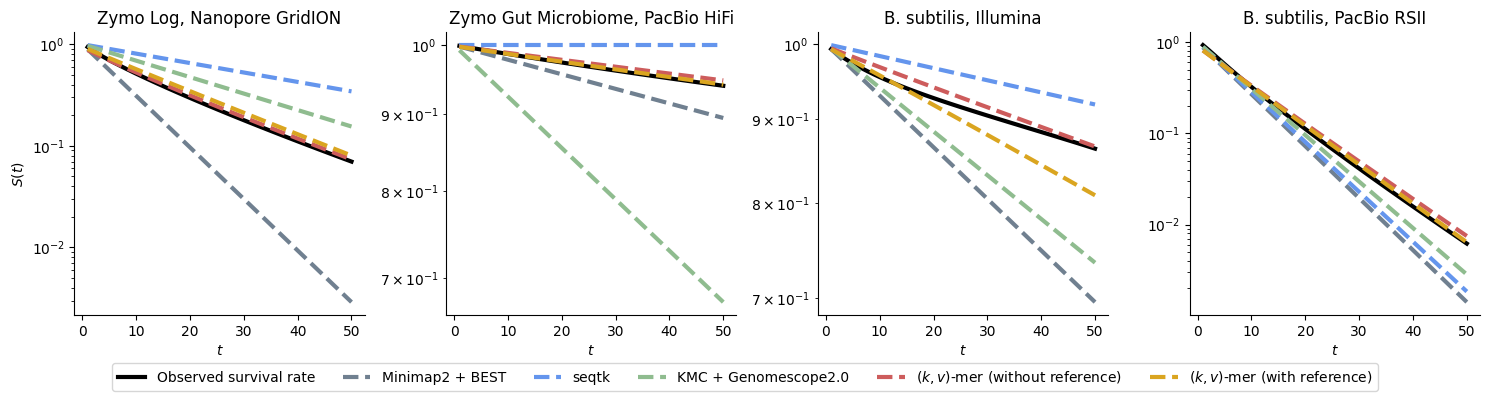

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_weibull(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return (alpha * beta) / (1 + beta * i)

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/SRR13128014.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv",
    
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio HiFi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    
]

kvmer_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer.csv",
    "../../output/zymo/SRR13128014_bi_kvmer.csv",
    "../../output/zymo/ERR2935851_bi_kvmer.csv",
    "../../output/zymo/SRR7498042_bi_kvmer.csv",
    
    #"../../output/human/HG002_hifi_bi_kvmer.csv"
    
]

kvmer_ref_report_csv = [
    "../../output/zymo/ERR3152366_kvmer_ref.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_ref.csv",
    "../../output/zymo/ERR2935851_kvmer_ref.csv",
    "../../output/zymo/SRR7498042_kvmer_ref.csv",
    
    #"../../output/human/HG002_hifi_bi_kvmer_ref.csv"
]

mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.997772,
    0.992763,
    0.868784,
    
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    82.9,
    27.7,
    9.0,
    
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.785707,
    0.613276,
    11.7262,
    
]



weibull_fit_results = []

for i in range(len(kvmer_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_report_csv[i])
    a = kvmer_report_df['a'].item()
    b = kvmer_report_df['b'].item()
    weibull_fit_results.append((a, b))

weibull_fit_results_ref = []
for i in range(len(kvmer_ref_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_report_csv[i])
    a = kvmer_report_df['a'].item()
    b = kvmer_report_df['b'].item()
    weibull_fit_results_ref.append((a, b))

def q_score_to_identity(q):
    return 1 - 10 ** (-q / 10)

def kmer_error_to_identity(e):
    return (1 - e / 100)

def estimate_survival_rate_from_identity(identity, k):
    return np.exp(-(1-identity) * k)

def estimate_survival_rate_list_from_beta(alpha, beta, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_beta(k, alpha, beta)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

def estimate_survival_rate_from_weibull(a, b, k):
    return np.exp(- a * ((k+1) ** np.exp(b)))

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
plot_range = range(1, 51)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    survival_rates_mapping = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(mapping_results[i], k)
        survival_rates_mapping.append(survival_rate)
    
    survival_rates_qscore = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(q_score_to_identity(q_score_results[i]), k)
        survival_rates_qscore.append(survival_rate)
    
    survival_rates_kmer = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(kmer_error_to_identity(kmer_results[i]), k)
        survival_rates_kmer.append(survival_rate)
    
    #survival_rates_beta = estimate_survival_rate_list_from_beta(beta_fit_results[i][0], beta_fit_results[i][1], plot_range.stop - 1)
    #survival_rates_beta = survival_rates_beta[plot_range.start - 1:plot_range.stop - 1]

    #survival_rates_const_hazard = []
    #for k in plot_range:
    #    survival_rate = (1 - (beta_fit_results[i][0] / (beta_fit_results[i][0] + beta_fit_results[i][1]))) ** k
    #    survival_rates_const_hazard.append(survival_rate)

    survival_rates_weibull = []
    survival_rates_weibull_ref = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_weibull(weibull_fit_results[i][0], weibull_fit_results[i][1], k)
        surival_rate_ref = estimate_survival_rate_from_weibull(weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1], k)
        survival_rates_weibull.append(survival_rate)
        survival_rates_weibull_ref.append(surival_rate_ref)

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)



    axes[i].plot(plot_range, survival_rates_plot, linewidth=3, label='Observed survival rate', color='black')
    axes[i].plot(plot_range, survival_rates_mapping, linewidth=3, linestyle='--', label='Minimap2 + BEST', color='slategray')
    axes[i].plot(plot_range, survival_rates_qscore, linewidth=3, linestyle='--', label='seqtk', color='cornflowerblue')
    axes[i].plot(plot_range, survival_rates_kmer, linewidth=3, linestyle='--', label='KMC + Genomescope2.0', color='darkseagreen')
    #axes[i].plot(plot_range, survival_rates_beta, linewidth=2, linestyle='-', label='Predicted from Beta Fit', color='C4')
    #axes[i].plot(plot_range, survival_rates_const_hazard, linewidth=2, linestyle='--', label='Predicted from Constant Hazard', color='C5')
    axes[i].plot(plot_range, survival_rates_weibull, linewidth=3, linestyle='--', label='$(k,v)$-mer (without reference)', color='indianred')
    axes[i].plot(plot_range, survival_rates_weibull_ref, linewidth=3, linestyle='--', label='$(k,v)$-mer (with reference)', color='goldenrod')

    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$S(t)$')
    #axes[i].legend()
    #axes[i].legend()

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=6)
fig.subplots_adjust(bottom=0.2)
#plt.tight_layout()


plt.savefig("../../figures/figure3_B.pdf")
#plt.ylim(0, 0.05)

[(0.010894, -0.111251), (0.034471, -0.124152), (0.001678, -0.063672)]
[(0.010894, -0.111251), (0.034471, -0.124152), (0.001678, -0.063672)]
[(0.006584, -0.040734), (0.023975, -0.052697), (0.001188, -0.030417)]
[0.9799491695257192, 0.9713075114179837, 0.9630421020858502, 0.9550613912819496, 0.9473122215974771, 0.9397597433480591, 0.9323792831087468, 0.9251524132182259, 0.9180648172702321, 0.9111050303116386, 0.9042636470973618, 0.8975327993964307, 0.8909057969479459, 0.8843768726259815, 0.8779409965317098, 0.8715937371597399, 0.8653311556064167, 0.8591497235266683, 0.8530462585170177, 0.8470178725211857, 0.8410619301267005, 0.8351760144838616, 0.82935789917602, 0.8236055247917552, 0.8179169792519922, 0.8122904811654239, 0.8067243656483083, 0.8012170721664272, 0.7957671340490916, 0.7903731693955411, 0.7850338731485181, 0.779748010152254, 0.7745144090454898, 0.769331956866633, 0.7641995942693, 0.7591163112635162, 0.754081143411619, 0.7490931684191503, 0.744151503070223, 0.7392553004644441

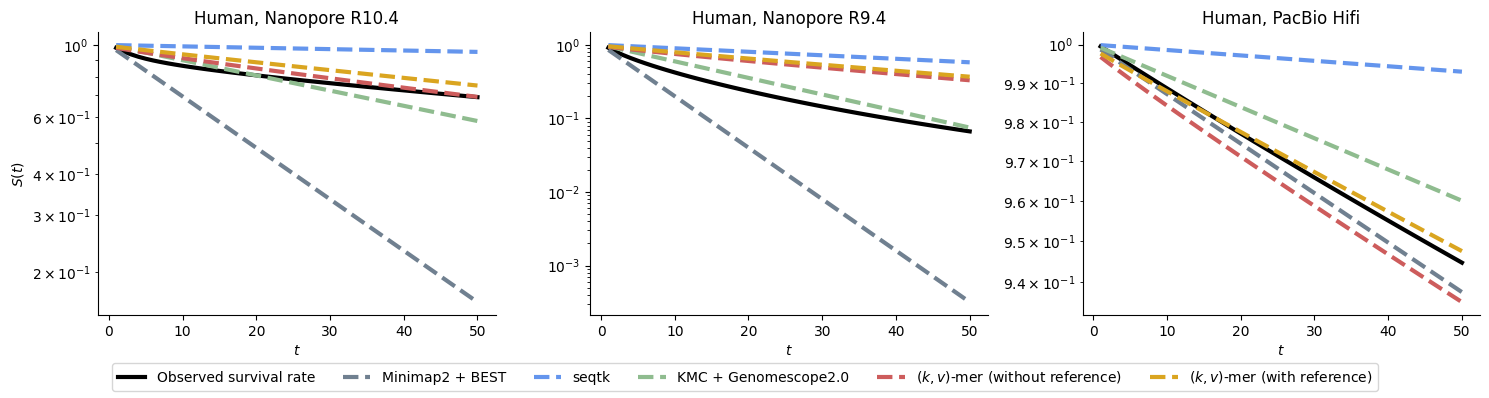

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_weibull(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return (alpha * beta) / (1 + beta * i)

kmer_hit_rate_csv = [
    "../../output/human/HG002.bam.tmp.0000.matched_kmers.csv",
    "../../output/human/HG002_R941.bam.tmp.0000.matched_kmers.csv",
    "../../output/human/HG002_hifi.bam.tmp.0000.matched_kmers.csv",
]


labels = [
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio Hifi",
]

kvmer_report_csv = [
    "../../output/human/HG002_bi_kvmer.csv",
    "../../output/human/HG002_R941_bi_kvmer.csv",
    "../../output/human/HG002_hifi_bi_kvmer.csv",
]

kvmer_ref_report_csv = [
    "../../output/human/HG002_bi_kvmer_ref.csv",
    "../../output/human/HG002_R941_bi_kvmer_ref.csv",
    "../../output/human/HG002_hifi_bi_kvmer_ref.csv",
]




mapping_results = [
    # Reported mapping identity by minimap2
    0.963613, # R10.4
    0.838991, # r9.4.1
    0.998709 # hifi
]

q_score_results = [
    # Reported ErrQ by seqtk
    30.1, # R10.4
    19.6, # R9.4.1
    38.5 # hifi
]

kmer_results = [
    # Reported error rate by GenomeScope
    1.076, # R10.4
    5.18148, # R9.4.1
    0.0814363, #hifi
]



weibull_fit_results = []

for i in range(len(kvmer_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_report_csv[i])
    a = kvmer_report_df['a'].item()
    b = kvmer_report_df['b'].item()
    weibull_fit_results.append((a, b))

weibull_fit_results_ref = []
for i in range(len(kvmer_ref_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_report_csv[i])
    a = kvmer_report_df['a'].item()
    b = kvmer_report_df['b'].item()
    weibull_fit_results_ref.append((a, b))

print(weibull_fit_results)

def q_score_to_identity(q):
    return 1 - 10 ** (-q / 10)

def kmer_error_to_identity(e):
    return (1 - e / 100)

def estimate_survival_rate_from_identity(identity, k):
    return np.exp(-(1-identity) * k)

def estimate_survival_rate_list_from_beta(alpha, beta, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_beta(k, alpha, beta)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

def estimate_survival_rate_from_weibull(a, b, k):
    return np.exp(- a * ((k+1) ** np.exp(b)))

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
plot_range = range(1, 51)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    survival_rates_mapping = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(mapping_results[i], k)
        survival_rates_mapping.append(survival_rate)
    
    survival_rates_qscore = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(q_score_to_identity(q_score_results[i]), k)
        survival_rates_qscore.append(survival_rate)
    
    survival_rates_kmer = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(kmer_error_to_identity(kmer_results[i]), k)
        survival_rates_kmer.append(survival_rate)
    
    #survival_rates_beta = estimate_survival_rate_list_from_beta(beta_fit_results[i][0], beta_fit_results[i][1], plot_range.stop - 1)
    #survival_rates_beta = survival_rates_beta[plot_range.start - 1:plot_range.stop - 1]

    #survival_rates_const_hazard = []
    #for k in plot_range:
    #    survival_rate = (1 - (beta_fit_results[i][0] / (beta_fit_results[i][0] + beta_fit_results[i][1]))) ** k
    #    survival_rates_const_hazard.append(survival_rate)

    survival_rates_weibull = []
    survival_rates_weibull_ref = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_weibull(weibull_fit_results[i][0], weibull_fit_results[i][1], k)
        surival_rate_ref = estimate_survival_rate_from_weibull(weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1], k)
        survival_rates_weibull.append(survival_rate)
        survival_rates_weibull_ref.append(surival_rate_ref)

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    print(weibull_fit_results)
    print(weibull_fit_results_ref)

    print(survival_rates_weibull)
    print(survival_rates_weibull_ref)   



    axes[i].plot(plot_range, survival_rates_plot, linewidth=3, label='Observed survival rate', color='black')
    axes[i].plot(plot_range, survival_rates_mapping, linewidth=3, linestyle='--', label='Minimap2 + BEST', color='slategray')
    axes[i].plot(plot_range, survival_rates_qscore, linewidth=3, linestyle='--', label='seqtk', color='cornflowerblue')
    axes[i].plot(plot_range, survival_rates_kmer, linewidth=3, linestyle='--', label='KMC + Genomescope2.0', color='darkseagreen')
    #axes[i].plot(plot_range, survival_rates_beta, linewidth=2, linestyle='-', label='Predicted from Beta Fit', color='C4')
    #axes[i].plot(plot_range, survival_rates_const_hazard, linewidth=2, linestyle='--', label='Predicted from Constant Hazard', color='C5')
    axes[i].plot(plot_range, survival_rates_weibull, linewidth=3, linestyle='--', label='$(k,v)$-mer (without reference)', color='indianred')
    axes[i].plot(plot_range, survival_rates_weibull_ref, linewidth=3, linestyle='--', label='$(k,v)$-mer (with reference)', color='goldenrod')

    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$S(t)$')
    #axes[i].legend()
    #axes[i].legend()

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=6)
fig.subplots_adjust(bottom=0.2)
#plt.tight_layout()


plt.savefig("../../figures/figureS1_B.pdf")
#plt.ylim(0, 0.05)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_weibull(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return (alpha * beta) / (1 + beta * i)

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv",
    "../../output/human/HG002.bam.tmp.0000.matched_kmers.csv"
    #"../../output/human/HG002_hifi.bam.tmp.0000.matched_kmers.csv"
]

labels = [
    "Zymo Log, GridION",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    "HG002, Nanopore R10.4"
]

kvmer_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer.csv",
    "../../output/zymo/ERR2935851_bi_kvmer.csv",
    "../../output/zymo/SRR7498042_bi_kvmer.csv",
    "../../output/human/HG002_bi_kvmer.csv"
    #"../../output/human/HG002_hifi_bi_kvmer.csv"
    
]

kvmer_ref_report_csv = [
    "../../output/zymo/ERR3152366_kvmer_ref.csv",
    "../../output/zymo/ERR2935851_kvmer_ref.csv",
    "../../output/zymo/SRR7498042_kvmer_ref.csv",
    "../../output/human/HG002_bi_kvmer_ref.csv"
    #"../../output/human/HG002_hifi_bi_kvmer_ref.csv"
]

mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.992763,
    0.868784,
    0.963613 # R10.4
    #0.838991 # r9.4.1
    #0.998709 # hifi
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    27.7,
    9.0,
    30.1 # R10.4
    #19.6 # R9.4.1
    #38.5 # hifi
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.613276,
    11.7262,
    1.076, # R10.4
    #5.18148 # R9.4.1
    #0.0814363 #hifi
]



weibull_fit_results = []

for i in range(len(kvmer_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_report_csv[i])
    a = kvmer_report_df['a'].item()
    b = kvmer_report_df['b'].item()
    weibull_fit_results.append((a, b))

weibull_fit_results_ref = []
for i in range(len(kvmer_ref_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_report_csv[i])
    a = kvmer_report_df['a'].item()
    b = kvmer_report_df['b'].item()
    weibull_fit_results_ref.append((a, b))

def q_score_to_identity(q):
    return 1 - 10 ** (-q / 10)

def kmer_error_to_identity(e):
    return (1 - e / 100)

def estimate_survival_rate_from_identity(identity, k):
    return identity ** k

def estimate_survival_rate_list_from_beta(alpha, beta, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_beta(k, alpha, beta)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

def estimate_survival_rate_from_weibull(a, b, k):
    return np.exp(- a * ((k+1) ** np.exp(b)))

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
plot_range = range(11, 51)
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    survival_rates_mapping = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(mapping_results[i], k)
        survival_rates_mapping.append(survival_rate)
    
    survival_rates_qscore = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(q_score_to_identity(q_score_results[i]), k)
        survival_rates_qscore.append(survival_rate)
    
    survival_rates_kmer = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(kmer_error_to_identity(kmer_results[i]), k)
        survival_rates_kmer.append(survival_rate)
    
    #survival_rates_beta = estimate_survival_rate_list_from_beta(beta_fit_results[i][0], beta_fit_results[i][1], plot_range.stop - 1)
    #survival_rates_beta = survival_rates_beta[plot_range.start - 1:plot_range.stop - 1]

    #survival_rates_const_hazard = []
    #for k in plot_range:
    #    survival_rate = (1 - (beta_fit_results[i][0] / (beta_fit_results[i][0] + beta_fit_results[i][1]))) ** k
    #    survival_rates_const_hazard.append(survival_rate)

    survival_rates_weibull = []
    survival_rates_weibull_ref = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_weibull(weibull_fit_results[i][0], weibull_fit_results[i][1], k)
        surival_rate_ref = estimate_survival_rate_from_weibull(weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1], k)
        survival_rates_weibull.append(survival_rate)
        survival_rates_weibull_ref.append(surival_rate_ref)


    axes[i].plot(plot_range, survival_rates_plot, linewidth=2, label='Observed K-mer Hit Rate', color='C0')
    axes[i].plot(plot_range, survival_rates_mapping, linewidth=2, linestyle='--', label='Predicted from Mapping Identity', color='C1')
    axes[i].plot(plot_range, survival_rates_qscore, linewidth=2, linestyle='--', label='Predicted from Q-Score', color='C2')
    axes[i].plot(plot_range, survival_rates_kmer, linewidth=2, linestyle='--', label='Predicted from K-mer Error Rate', color='C3')
    #axes[i].plot(plot_range, survival_rates_beta, linewidth=2, linestyle='-', label='Predicted from Beta Fit', color='C4')
    #axes[i].plot(plot_range, survival_rates_const_hazard, linewidth=2, linestyle='--', label='Predicted from Constant Hazard', color='C5')
    axes[i].plot(plot_range, survival_rates_weibull, linewidth=2, linestyle='--', label='Predicted from Weibull Fit', color='C4')
    axes[i].plot(plot_range, survival_rates_weibull_ref, linewidth=2, linestyle='--', label='Predicted from Weibull Fit (with ref)', color='C5')

    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    
    axes[i].set_xlabel('t')
    if i  == 0:
        axes[i].set_ylabel('S(t)')
    axes[i].legend()
    axes[i].legend()

plt.tight_layout()


plt.show()
#plt.ylim(0, 0.05)

NameError: name 'beta_fit_results' is not defined

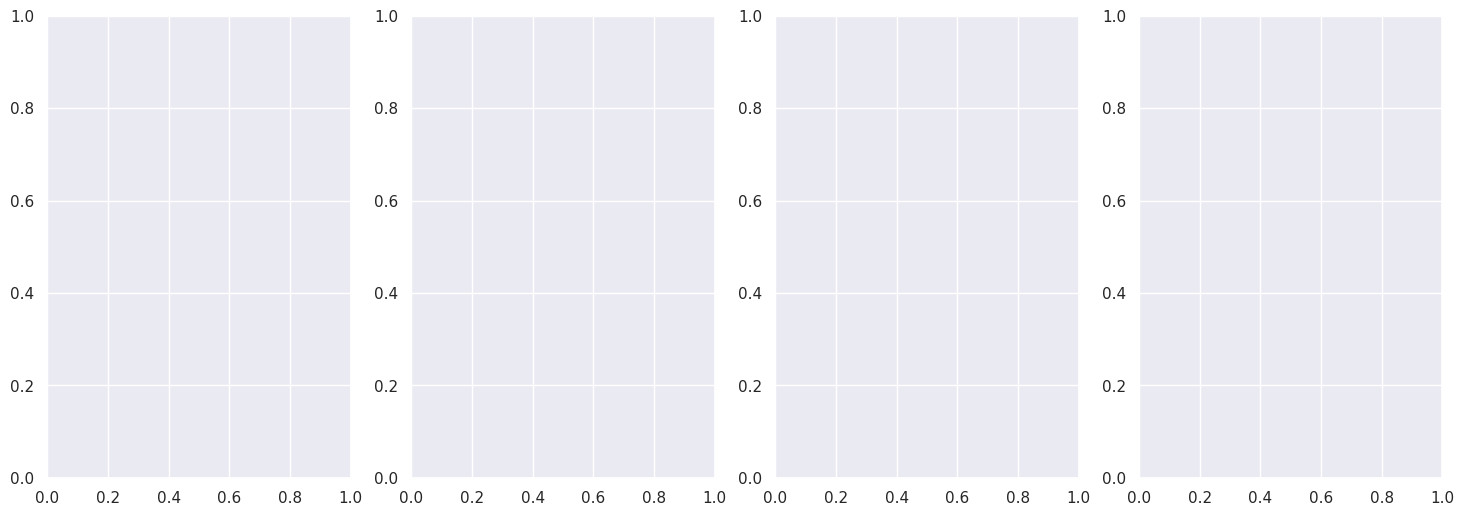

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_weibull(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return (alpha * beta) / (1 + beta * i)

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/ERR2935851_trim_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv",
    "../../output/human/HG002_hifi.bam.tmp.0000.matched_kmers.csv"
]

labels = [
    "Zymo Log, GridION",
    "B. subtilis, Illumina (trimmed)",
    "B. subtilis, PacBio RSII",
    "HG002, Nanopore R10.4"
]

mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.994679,
    0.868784,
    0.963613
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    27.7,
    9.0,
    30.1
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.613276,
    11.7262,
    0.4,
]


weibull_fit_results = [
    (0.053066, -0.022761),
    (0.002119, 0.082222),
    (0.099610, -0.019108),
    (0.027105693874757093, 0.0)
]

def q_score_to_identity(q):
    return 1 - 10 ** (-q / 10)

def kmer_error_to_identity(e):
    return (1 - e / 100)

def estimate_survival_rate_from_identity(identity, k):
    return identity ** k

def estimate_survival_rate_list_from_beta(alpha, beta, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_beta(k, alpha, beta)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

def estimate_survival_rate_list_from_weibull(a, b, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_weibull(k, a, b)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
plot_range = range(11, 100)
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    survival_rates_mapping = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(mapping_results[i], k)
        survival_rates_mapping.append(survival_rate)
    
    survival_rates_qscore = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(q_score_to_identity(q_score_results[i]), k)
        survival_rates_qscore.append(survival_rate)
    
    survival_rates_kmer = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(kmer_error_to_identity(kmer_results[i]), k)
        survival_rates_kmer.append(survival_rate)
    
    #survival_rates_beta = estimate_survival_rate_list_from_beta(beta_fit_results[i][0], beta_fit_results[i][1], plot_range.stop - 1)
    #survival_rates_beta = survival_rates_beta[plot_range.start - 1:plot_range.stop - 1]

    survival_rates_const_hazard = []
    for k in plot_range:
        survival_rate = (1 - (beta_fit_results[i][0] / (beta_fit_results[i][0] + beta_fit_results[i][1]))) ** k
        survival_rates_const_hazard.append(survival_rate)

    survival_rates_weibull = estimate_survival_rate_list_from_weibull(weibull_fit_results[i][0], weibull_fit_results[i][1], plot_range.stop - 1)
    survival_rates_weibull = survival_rates_weibull[plot_range.start - 1:plot_range.stop - 1]

    axes[i].plot(plot_range, survival_rates_plot, linewidth=2, label='Observed K-mer Hit Rate', color='C0')
    axes[i].plot(plot_range, survival_rates_mapping, linewidth=2, linestyle='--', label='Predicted from Mapping Identity', color='C1')
    axes[i].plot(plot_range, survival_rates_qscore, linewidth=2, linestyle='--', label='Predicted from Q-Score', color='C2')
    axes[i].plot(plot_range, survival_rates_kmer, linewidth=2, linestyle='--', label='Predicted from K-mer Error Rate', color='C3')
    #axes[i].plot(plot_range, survival_rates_beta, linewidth=2, linestyle='-', label='Predicted from Beta Fit', color='C4')
    #axes[i].plot(plot_range, survival_rates_const_hazard, linewidth=2, linestyle='--', label='Predicted from Constant Hazard', color='C5')
    axes[i].plot(plot_range, survival_rates_weibull, linewidth=2, linestyle='--', label='Predicted from Weibull Fit', color='C6')

    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    
    axes[i].set_xlabel('t')
    if i % 2 == 0:
        axes[i].set_ylabel('h(t)')
    #axes[i].legend()
    axes[i].legend()

plt.tight_layout()


plt.show()
#plt.ylim(0, 0.05)